In [108]:
from lifelines import KaplanMeierFitter
from lifelines import AalenJohansenFitter
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lifelines import CoxPHFitter

In [109]:
#Dataframe Notes: 0 = cancer (relapse?), 1 = lost to follow up, 2 = death, competiting
#DT_SECONDCANCER_DEATH, ENDPT_SECONDCANCER_DEATH,
df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")

C:\Users\Charm\AppData\Local\Temp\ipykernel_6172\80286513.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\Charm\Downloads\data_clinical_sample_ttnext_cancer_6-2-26.csv")


In [110]:
sorted_df = df.sort_values(by = 'CURRENT_AGE_DEID')
dt = sorted_df['DT_SECONDCANCER_DEATH']
censored_val = sorted_df['ENDPT_SECONDCANCER_DEATH']
curr_age = sorted_df['CURRENT_AGE_DEID']

Lets just look at first biopsies then go from there. Update: No repeating patients, so it's okay!

In [111]:
df['SAMPLE_ID'].duplicated().sum()

np.int64(0)

In [112]:
#If time is negative, set it to 0.
sorted_df.loc[sorted_df['DT_SECONDCANCER_DEATH']<0, 'DT_SECONDCANCER_DEATH'] = 0
#DT_SECONDCANCER_DEATH is Last Date - Start Date, is start date when the patient was diagnosed cancer free from the primary lung cancer and then we're tracking how long it takes for the patient to die or develop second primary lung cancer or is lost to follow up, or is start date the day the patient was diagnosed with the first cancer? The former makes more sense, so I'm assuming the data is left censored and instead of just setting those dates to 0, I'll remove  them.
#sorted_df = sorted_df.loc[(sorted_df['DT_SECONDCANCER_DEATH']>=0).values]

In [113]:
#If we only want 1 to represent the observed effect
sorted_df['Event_of_interest'] =(sorted_df['ENDPT_SECONDCANCER_DEATH'] == 1).astype(int)
sorted_df['Event_of_interest']

11896    0
2874     0
1280     0
9170     0
2305     0
        ..
4205     1
10505    0
4225     0
4226     0
8404     0
Name: Event_of_interest, Length: 12306, dtype: int64

<Axes: >

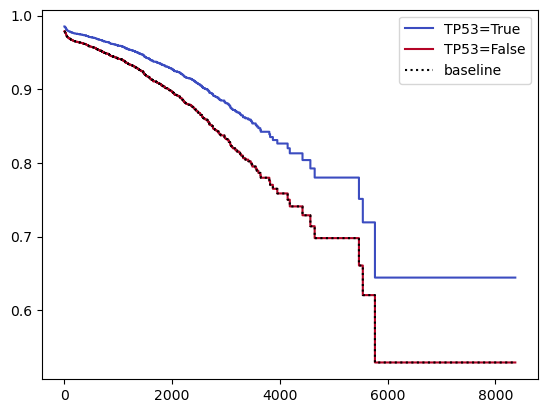

In [114]:
#Filter the df so that I don't get a value error because of the text columns...
cph_df = sorted_df[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS', 'EGFR', 'ALK', 'BRAF', 'ROS1', 'MET', 'ENDPT_SECONDCANCER_DEATH']]
cph = CoxPHFitter()
cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
cph.plot_partial_effects_on_outcome(covariates='TP53', values=[True, False], cmap='coolwarm')

Proportional Hazard Assumption: All Individuals have the same hazard function and differ by a scalar, and that scalar does not vary with time.

In [115]:
cph.print_summary(model = 'untransformed variables', decimals = 3)

AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 12306 total observations, 11488 right-censored observations>
             duration col = 'DT_SECONDCANCER_DEATH'
                event col = 'Event_of_interest'
      baseline estimation = breslow
   number of observations = 12306
number of events observed = 818
   partial log-likelihood = -6992.672
         time fit was run = 2026-06-10 15:01:27 UTC
                    model = untransformed variables

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
TP53                      -0.370     0.690     0.074          -0.515          -0.226               0.597               0.798
CURRENT_AGE_DEID           0.015     1.015     0.004           0.008           0.022               1.008               1.022
KRAS                       0.282     1.326     0.082           0.121           0.443               1.129               1.557
EGFR                      -0.130     0.878     0.094          -0.315           0.055               0.730               1.057
ALK                       -0.046     0.955     1.002          -2.009           1.918               0.134               6.805
BRAF                       0.398     1.488     0.160           0.085           0.711               1.088               2.035
ROS1                     -11.720     0.000   538.807       -1067.763        1044.322               0.000                 inf
MET                        0.393     1.482     0.145           0.108           0.678               1.115               1.970
ENDPT_SECONDCANCER_DEATH   0.182     1.199     0.037           0.108           0.255               1.114               1.291

                          cmp to      z       p  -log2(p)
covariate                                                
TP53                       0.000 -5.017 <0.0005    20.864
CURRENT_AGE_DEID           0.000  4.271 <0.0005    15.648
KRAS                       0.000  3.433   0.001    10.710
EGFR                       0.000 -1.374   0.169     2.561
ALK                        0.000 -0.045   0.964     0.053
BRAF                       0.000  2.490   0.013     6.291
ROS1                       0.000 -0.022   0.983     0.025
MET                        0.000  2.706   0.007     7.199
ENDPT_SECONDCANCER_DEATH   0.000  4.843 <0.0005    19.575
---
Concordance = 0.620
Partial AIC = 14003.344
log-likelihood ratio test = 112.899 on 9 df
-log2(p) of ll-ratio test = 64.523

In [116]:
#[i for i in sorted_df['CURRENT_AGE_DEID'].values]

In [117]:
#cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest')
#cph.plot_partial_effects_on_outcome(covariates='CURRENT_AGE_DEID', values=[i for i in sorted_df['CURRENT_AGE_DEID'].values], cmap='coolwarm')


In [118]:
print(sorted_df['Event_of_interest'].dtypes, sorted_df['DT_SECONDCANCER_DEATH'].dtypes)

int64 int64


Let's make a cumulative incidence function, since lifelines doesn't have fine gray, we can use Aalen Johansen but it doesn't account for covariants (whereas the Cox Proportional Hazard Function accounts for covariants but not for competing factors...)

C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


                 CIF_1
event_at              
-0.000100     0.000000
-0.000099     0.000000
-0.000099     0.000000
-0.000098     0.000000
-0.000098     0.000000
...                ...
 7355.000000  0.113561
 7498.000046  0.113561
 7853.000077  0.113561
 8304.999905  0.113561
 8372.000000  0.113561

[9492 rows x 1 columns]


Text(0, 0.5, 'Probability')

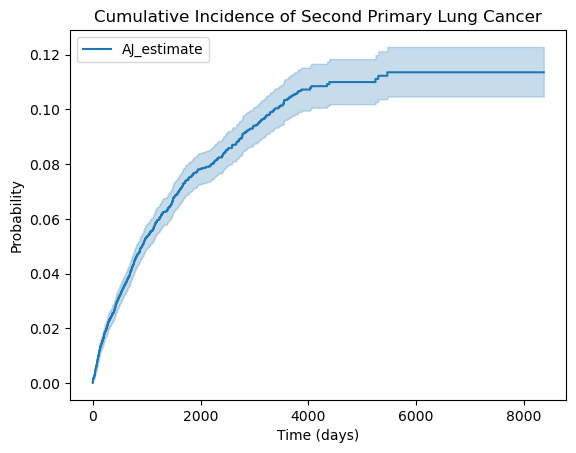

In [155]:
ajf = AalenJohansenFitter(calculate_variance = True)
ajf.fit(cph_df['DT_SECONDCANCER_DEATH'], cph_df['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
print(ajf.cumulative_density_)
#ajf.plot()
ajf.plot()
plt.title('Cumulative Incidence of Second Primary Lung Cancer')
plt.xlabel('Time (days)')
plt.ylabel('Probability')

So the rate for someone who has experienced a first primary cancer experiencing a second primary cancer is 46% ?

Let's stratifying between people with TP53 mutation and those without.

In [120]:
mutated_TP53 = cph_df[cph_df['TP53'] == True]
nonmutated_TP53 = cph_df[cph_df['TP53'] == False]

C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


Text(0, 0.5, 'Probability')

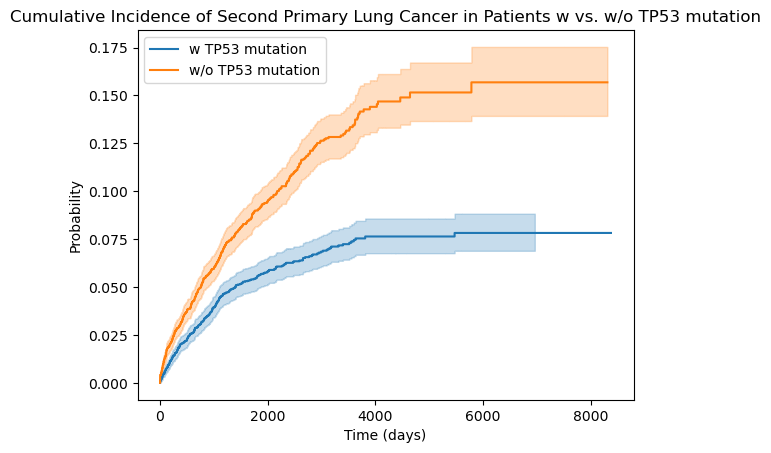

In [156]:
TP53m_ajf = AalenJohansenFitter(calculate_variance = True)
TP53nm_ajf = AalenJohansenFitter(calculate_variance = True)
TP53m_ajf.fit(mutated_TP53['DT_SECONDCANCER_DEATH'], mutated_TP53['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
TP53m_ajf.cumulative_density_
TP53m_ajf.plot(label = 'w TP53 mutation')
TP53nm_ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
TP53nm_ajf.cumulative_density_
TP53nm_ajf.plot(label = 'w/o TP53 mutation')
plt.title('Cumulative Incidence of Second Primary Lung Cancer in Patients w vs. w/o TP53 mutation')
plt.xlabel('Time (days)')
plt.ylabel('Probability')
#Blue is mutated, Orange is unmutated

Weird result, lets see if ppl who have TP53 mutation generally die faster than those without the mutation => incidence is lower because those with a TP53 mutation die before getting a second primary cancer.

In [131]:
print(mutated_TP53['ENDPT_SECONDCANCER_DEATH'].value_counts(normalize = True))
#57% of ppl with TP53 mutation die before second primary cancer is developed.
print(nonmutated_TP53['ENDPT_SECONDCANCER_DEATH'].value_counts(normalize = True))
#41% of ppl with nonmutated TP53 die before second primary cancer is developed.

ENDPT_SECONDCANCER_DEATH
2    0.570568
0    0.379782
1    0.049650
Name: proportion, dtype: float64
ENDPT_SECONDCANCER_DEATH
0    0.503326
2    0.413435
1    0.083239
Name: proportion, dtype: float64


C:\Users\Charm\AppData\Local\Temp\ipykernel_6172\914604884.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cph_df['Age Buckets'] = pd.cut(sorted_df['CURRENT_AGE_DEID'], bins=[0, 25, 75, 100], labels=['0-24', '25-74', '75-100'])
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1868: FutureWarning: The default of observed=F

<Axes: xlabel='log(HR) (95% CI)'>

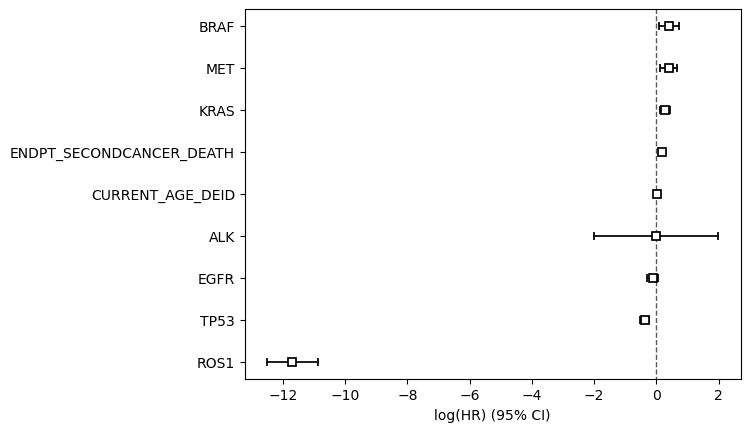

In [122]:
cph_df['Age Buckets'] = pd.cut(sorted_df['CURRENT_AGE_DEID'], bins=[0, 25, 75, 100], labels=['0-24', '25-74', '75-100'])
#print(cph_df['Age Buckets'])
cph.fit(cph_df, duration_col = 'DT_SECONDCANCER_DEATH', event_col = 'Event_of_interest', strata = 'Age Buckets', robust = True)
cph.plot()

If the individual developed a secondary cancer, lets see how high the incidence is for someone with a TP53 and KRAS mutation

C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


Text(0, 0.5, 'Probability')

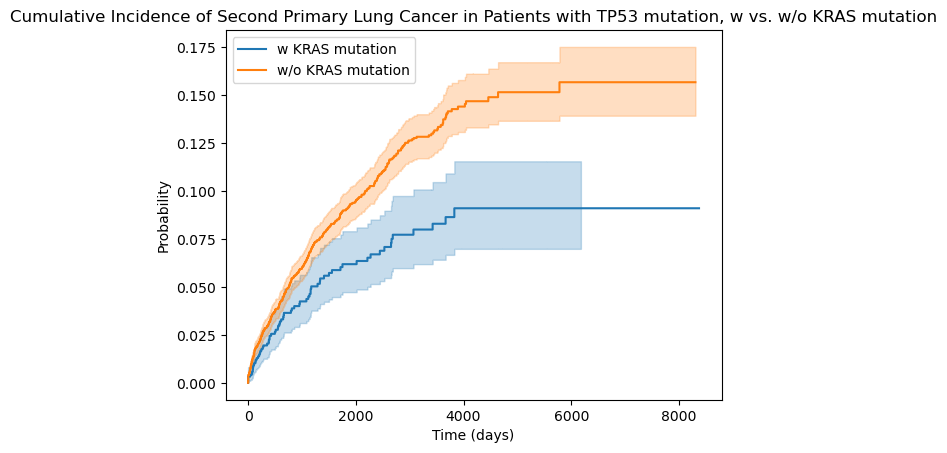

In [159]:
TP53KRASm_ajf = AalenJohansenFitter(calculate_variance = True)
TP53nm_ajf = AalenJohansenFitter(calculate_variance = True)
mutated_TP53_KRAS = mutated_TP53[mutated_TP53['KRAS'] == True]
TP53KRASm_ajf.fit(mutated_TP53_KRAS['DT_SECONDCANCER_DEATH'], mutated_TP53_KRAS['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
TP53KRASm_ajf.cumulative_density_
TP53KRASm_ajf.plot(label ='w KRAS mutation')
TP53nm_ajf.fit(nonmutated_TP53['DT_SECONDCANCER_DEATH'], nonmutated_TP53['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
TP53nm_ajf.cumulative_density_
TP53nm_ajf.plot(label ='w/o KRAS mutation')
plt.title('Cumulative Incidence of Second Primary Lung Cancer in Patients with TP53 mutation, w vs. w/o KRAS mutation')
plt.xlabel('Time (days)')
plt.ylabel('Probability')

Lets look at how age impacts CIF


C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


Text(0, 0.5, 'Probability')

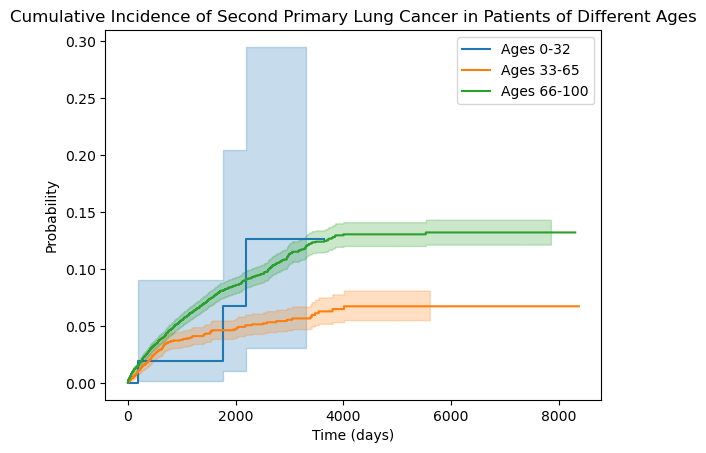

In [162]:
young_ajf = AalenJohansenFitter(calculate_variance = True)
middle_ajf = AalenJohansenFitter(calculate_variance = True)
old_ajf = AalenJohansenFitter(calculate_variance = True)
group_1 = cph_df[cph_df['CURRENT_AGE_DEID'] <= 32]
group_2 = cph_df[(cph_df['CURRENT_AGE_DEID'] <= 65) & (cph_df['CURRENT_AGE_DEID'] > 32)]
group_3 = cph_df[(cph_df['CURRENT_AGE_DEID'] <= 99) & (cph_df['CURRENT_AGE_DEID'] > 65)]
young_ajf.fit(group_1['DT_SECONDCANCER_DEATH'], group_1['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
young_ajf.cumulative_density_
young_ajf.plot(label = 'Ages 0-32')
middle_ajf.fit(group_2['DT_SECONDCANCER_DEATH'], group_2['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
middle_ajf.cumulative_density_
middle_ajf.plot(label = 'Ages 33-65')
old_ajf.fit(group_3['DT_SECONDCANCER_DEATH'], group_3['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
old_ajf.cumulative_density_
old_ajf.plot(label = 'Ages 66-100')
plt.title('Cumulative Incidence of Second Primary Lung Cancer in Patients of Different Ages')
plt.xlabel('Time (days)')
plt.ylabel('Probability')
#Blue, orange, green

That group 1 data looks weird !

In [145]:
print(len(group_1), len(group_2), len(group_3))
print(group_1['ENDPT_SECONDCANCER_DEATH'].value_counts(normalize = True))
print(group_2['ENDPT_SECONDCANCER_DEATH'].value_counts(normalize = True))
print(group_3['ENDPT_SECONDCANCER_DEATH'].value_counts(normalize = True))
#Pretty similar percentage of people die before developing a secondary primary cancer.

61 3575 8670
ENDPT_SECONDCANCER_DEATH
2    0.508197
0    0.442623
1    0.049180
Name: proportion, dtype: float64
ENDPT_SECONDCANCER_DEATH
2    0.537343
0    0.422378
1    0.040280
Name: proportion, dtype: float64
ENDPT_SECONDCANCER_DEATH
2    0.473010
0    0.449596
1    0.077393
Name: proportion, dtype: float64


Let's compare incidence based on stage of cancer.

In [125]:
sorted_df['STAGE_HIGHEST_RECORDED'].unique()

array(['Unknown', 'Stage 1-3', 'Stage 4'], dtype=object)

C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


Text(0, 0.5, 'Probability')

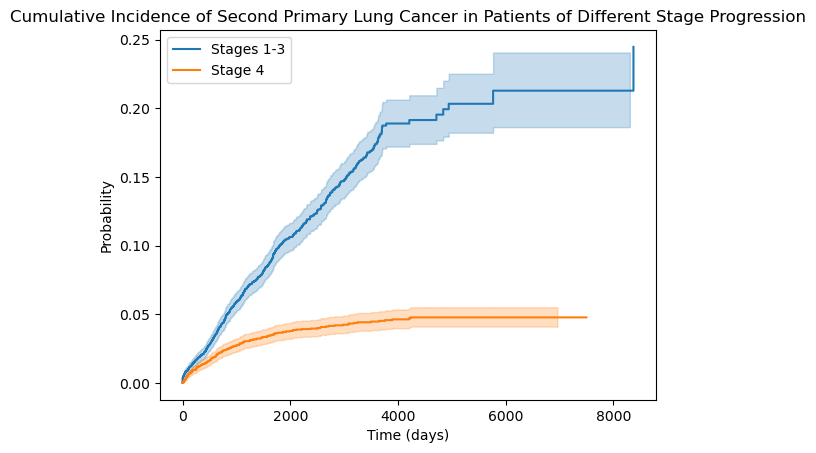

In [164]:
stage13_ajf = AalenJohansenFitter(calculate_variance = True)
stage4_ajf = AalenJohansenFitter(calculate_variance = True)
sorted_df_S13 = sorted_df[sorted_df['STAGE_HIGHEST_RECORDED'] == 'Stage 1-3']
group_1 = sorted_df_S13[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS', 'ENDPT_SECONDCANCER_DEATH']]
sorted_df_S4 = sorted_df[sorted_df['STAGE_HIGHEST_RECORDED'] == 'Stage 4']
group_2 = sorted_df_S4[['DT_SECONDCANCER_DEATH', 'Event_of_interest', 'TP53', 'CURRENT_AGE_DEID', 'KRAS', 'ENDPT_SECONDCANCER_DEATH']]
stage13_ajf.fit(group_1['DT_SECONDCANCER_DEATH'], group_1['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
stage13_ajf.cumulative_density_
stage13_ajf.plot(label = 'Stages 1-3')
stage4_ajf.fit(group_2['DT_SECONDCANCER_DEATH'], group_2['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
stage4_ajf.cumulative_density_
stage4_ajf.plot(label = 'Stage 4')
plt.title('Cumulative Incidence of Second Primary Lung Cancer in Patients of Different Stage Progression')
plt.xlabel('Time (days)')
plt.ylabel('Probability')

Seems like a similar situation to TP53, those with Stage 1-3 primary lung cancer more likely to develop a second primary lung cancer than those with Stage 4 primary lung cancer because they're more likely to die first...

In [135]:
print(group_1['ENDPT_SECONDCANCER_DEATH'].value_counts(normalize = True))
#36% of ppl with Stage 1-3 primary lung cancer die before second primary cancer is developed.
print(group_2['ENDPT_SECONDCANCER_DEATH'].value_counts(normalize = True))
#71% of ppl with Stage 4 primary lung cancer die before second primary cancer is developed.

ENDPT_SECONDCANCER_DEATH
0    0.538315
2    0.357921
1    0.103765
Name: proportion, dtype: float64
ENDPT_SECONDCANCER_DEATH
2    0.715342
0    0.249384
1    0.035274
Name: proportion, dtype: float64


Let's combine the analysis to ask if you're older (75+) and have a KRAS mutation, are you at a higher risk for a second primary cancer than someone in the same age range than someone who does not have the mutation?

In [165]:
oldKRASm_ajf = AalenJohansenFitter(calculate_variance = True)
oldKRASnm_ajf = AalenJohansenFitter(calculate_variance = True)
older_ppl_w_KRAS = cph_df[(cph_df['CURRENT_AGE_DEID'] >= 75) & (cph_df['KRAS'] == True)]
older_ppl_wo_KRAS = cph_df[(cph_df['CURRENT_AGE_DEID'] >= 75) & (cph_df['KRAS'] == False)]

C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
C:\Users\Charm\.conda\envs\MSKSurvivalAnalyses\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


Text(0, 0.5, 'Probability')

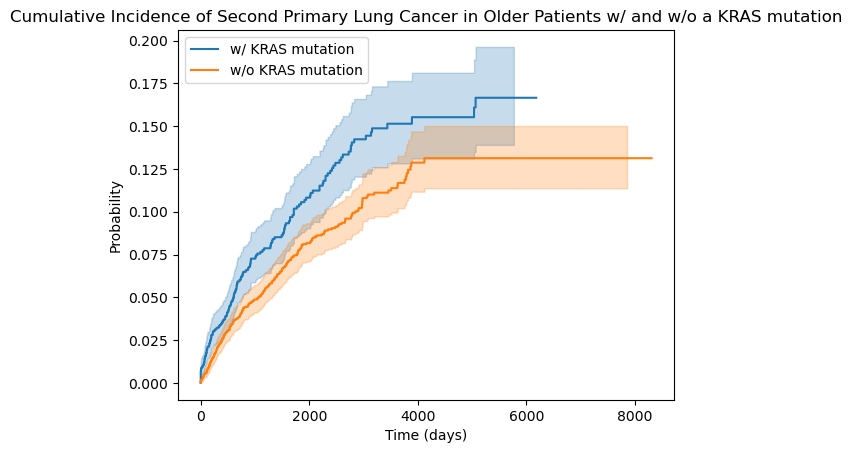

In [166]:
oldKRASm_ajf.fit(older_ppl_w_KRAS['DT_SECONDCANCER_DEATH'], older_ppl_w_KRAS['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
oldKRASm_ajf.cumulative_density_
oldKRASm_ajf.plot(label = 'w/ KRAS mutation')
oldKRASnm_ajf.fit(older_ppl_wo_KRAS['DT_SECONDCANCER_DEATH'], older_ppl_wo_KRAS['ENDPT_SECONDCANCER_DEATH'], event_of_interest=1)
oldKRASnm_ajf.cumulative_density_
oldKRASnm_ajf.plot(label = 'w/o KRAS mutation')
plt.title('Cumulative Incidence of Second Primary Lung Cancer in Older Patients w/ and w/o a KRAS mutation')
plt.xlabel('Time (days)')
plt.ylabel('Probability')